In [5]:
import os
import pandas as pd

script_dir = os.getcwd()
df = pd.read_csv(os.path.join(script_dir, 'CarRevised.csv'))
df.head()

,Company Names,Cars Names,Engines,CC/Battery Capacity,Horse Power Final,Total Speed,Performance(0 - 100 )KM/H,Car Prices Final,Fuel Types,Seats,Torque Final
0,Bugatti,La Voiture Noire,8.0L Quad-Turbo W16,7993.0,1500.0,420.0,2.5,18000000.0,Petrol,2,1600.0
1,Bugatti,Centodieci,8.0L Quad-Turbo W16,7993.0,1600.0,380.0,2.4,9000000.0,Petrol,2,1600.0
2,Mazda,787B (Race Car),2.6L Wankel Rotary Engine,2620.0,700.0,320.0,3.5,6000000.0,Petrol,1,500.0
3,Bugatti,Divo,8.0L Quad-Turbo W16,7993.0,1500.0,380.0,2.4,5800000.0,Petrol,2,1600.0
4,Bugatti,Mistral,8.0L Quad-Turbo W16,7993.0,1600.0,420.0,2.4,5000000.0,Petrol,2,1600.0


In [6]:
df.shape

(1202, 11)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1202 entries, 0 to 1201
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Company Names              1202 non-null   str    
 1   Cars Names                 1202 non-null   str    
 2   Engines                    1202 non-null   str    
 3   CC/Battery Capacity        979 non-null    float64
 4   Horse Power Final          1018 non-null   float64
 5   Total Speed                1201 non-null   float64
 6   Performance(0 - 100 )KM/H  1183 non-null   float64
 7   Car Prices Final           1196 non-null   float64
 8   Fuel Types                 1202 non-null   str    
 9   Seats                      1202 non-null   int64  
 10  Torque Final               1192 non-null   float64
dtypes: float64(6), int64(1), str(4)
memory usage: 103.4 KB


In [8]:
df.describe()

,CC/Battery Capacity,Horse Power Final,Total Speed,Performance(0 - 100 )KM/H,Car Prices Final,Seats,Torque Final
count,979.000000,1018.000000,1201.000000,1183.000000,1.196000e+03,1202.000000,1192.000000
mean,3101.596527,311.201375,216.368027,7.580135,1.396426e+05,4.878536,511.106544
std,1881.694953,219.790196,53.130322,3.335605,7.171495e+05,1.555594,1059.864621
min,360.000000,26.000000,80.000000,1.900000,4.000000e+03,1.000000,45.000000
25%,1800.000000,160.000000,180.000000,5.200000,2.800000e+04,4.000000,250.000000
50%,2500.000000,255.000000,200.000000,7.100000,4.264750e+04,5.000000,373.000000
75%,3800.000000,401.000000,250.000000,9.500000,7.000000e+04,5.000000,563.000000
max,16100.000000,1850.000000,500.000000,35.000000,1.800000e+07,20.000000,15590.000000


In [9]:
df.sort_values('Torque Final', ascending=False).head(5)

,Company Names,Cars Names,Engines,CC/Battery Capacity,Horse Power Final,Total Speed,Performance(0 - 100 )KM/H,Car Prices Final,Fuel Types,Seats,Torque Final
174,Gmc,Hummer EV SUV Extreme Off-Road,"Electric motors with up to 11,500 lb-ft torque",NaN,NaN,170.0,3.6,110000.0,Electric,5,15590.0
210,Gmc,Hummer EV Pickup Edition 1,"Electric motors with up to 11,500 lb-ft torque",NaN,NaN,170.0,3.0,96550.0,Electric,5,15590.0
171,Gmc,Hummer EV Omega Edition,"Electric motors with up to 11,500 lb-ft torque",NaN,NaN,170.0,3.0,112700.0,Electric,5,15590.0
188,Gmc,Hummer EV Adventure Series,"Electric motors with up to 11,500 lb-ft torque",NaN,NaN,170.0,3.6,105000.0,Electric,5,15590.0
209,Gmc,Hummer EV SUV Edition 1,"Electric motors with up to 11,500 lb-ft torque",NaN,NaN,170.0,3.5,96550.0,Electric,5,15590.0


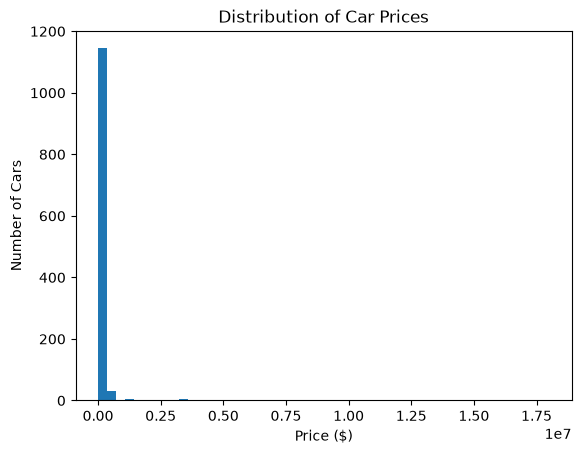

In [10]:
import matplotlib.pyplot as plt

plt.hist(df['Car Prices Final'].dropna(), bins=50)
plt.xlabel('Price ($)')
plt.ylabel('Number of Cars')
plt.title('Distribution of Car Prices')
plt.show()

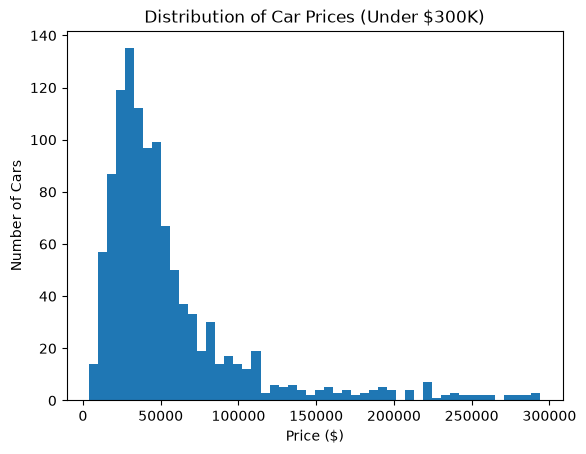

In [11]:
# Zooming in on cars under $300,000 to see the shape of the "typical" market
plt.hist(df[df['Car Prices Final'] < 300000]['Car Prices Final'].dropna(), bins=50)
plt.xlabel('Price ($)')
plt.ylabel('Number of Cars')
plt.title('Distribution of Car Prices (Under $300K)')
plt.show()

In [ ]:
plt.scatter(df['Horse Power Final'], df['Car Prices Final'], alpha=0.3)
plt.xlabel('Horsepower')
plt.ylabel('Price ($)')
plt.title('Horsepower vs. Price')
plt.show()

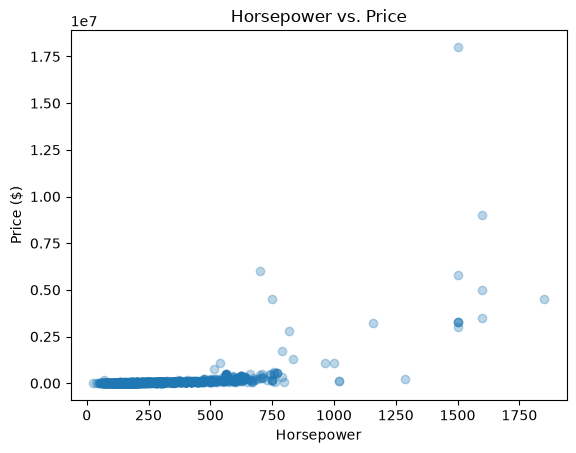

In [12]:
plt.scatter(df['Horse Power Final'], df['Car Prices Final'], alpha=0.3)
plt.xlabel('Horsepower')
plt.ylabel('Price ($)')
plt.title('Horsepower vs. Price')
plt.show()

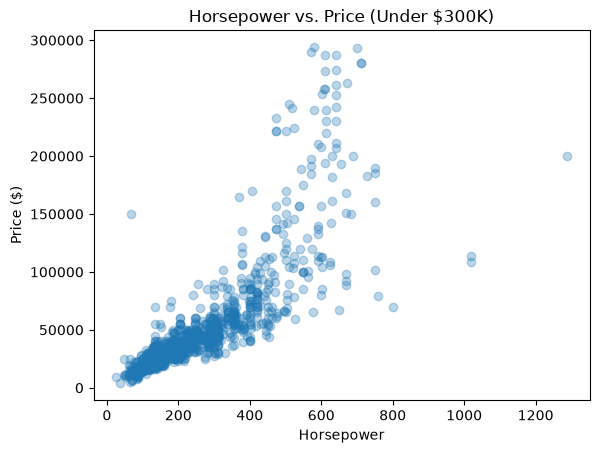

In [13]:
# Zooming in on cars under $300,000 to see the horsepower-price relationship clearly
subset = df[df['Car Prices Final'] < 300000]
plt.scatter(subset['Horse Power Final'], subset['Car Prices Final'], alpha=0.3)
plt.xlabel('Horsepower')
plt.ylabel('Price ($)')
plt.title('Horsepower vs. Price (Under $300K)')
plt.show()

In [14]:
df[(df['Horse Power Final'] > 900) & (df['Car Prices Final'] < 250000)][['Company Names', 'Cars Names', 'Horse Power Final', 'Car Prices Final']]

,Company Names,Cars Names,Horse Power Final,Car Prices Final
106,Tesla,Roadster 2,1288.0,200000.0
166,Tesla,Model X Plaid,1020.0,113490.0
182,Tesla,Model S Plaid,1020.0,108490.0


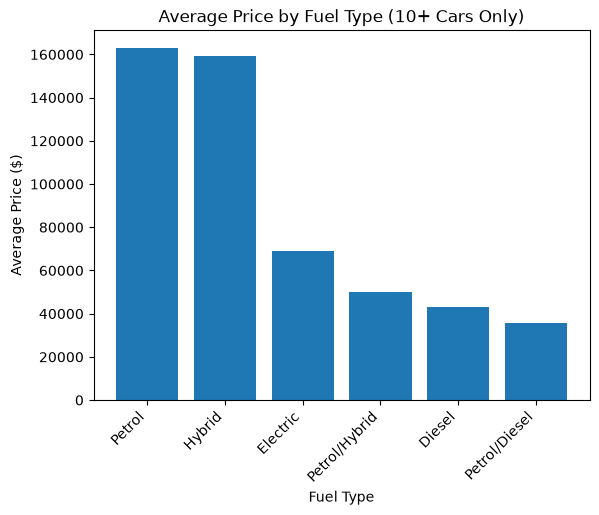

In [15]:
# Grouping by fuel type and calculating average price, keeping only fuel types with 10+ cars
fuel_avg = df.groupby('Fuel Types')['Car Prices Final'].mean()
fuel_counts = df['Fuel Types'].value_counts()
fuel_avg_filtered = fuel_avg[fuel_counts >= 10].sort_values(ascending=False)

plt.bar(fuel_avg_filtered.index, fuel_avg_filtered.values)
plt.xlabel('Fuel Type')
plt.ylabel('Average Price ($)')
plt.title('Average Price by Fuel Type (10+ Cars Only)')
plt.xticks(rotation=45, ha='right')
plt.show()

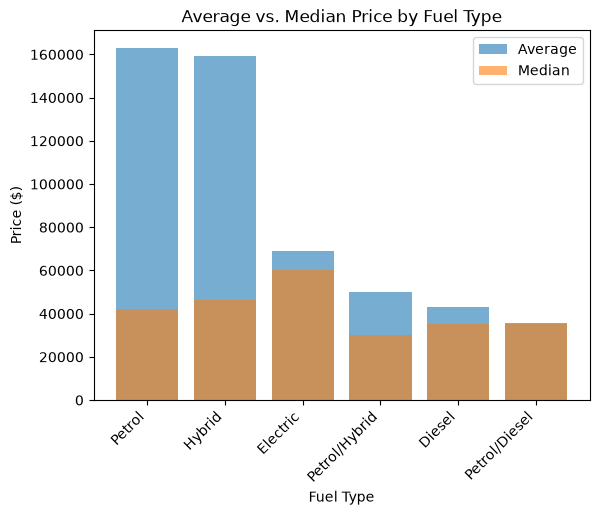

In [16]:
# Comparing average vs median price by fuel type
fuel_median = df.groupby('Fuel Types')['Car Prices Final'].median()
fuel_median_filtered = fuel_median[fuel_counts >= 10].sort_values(ascending=False)

plt.bar(fuel_avg_filtered.index, fuel_avg_filtered.values, alpha=0.6, label='Average')
plt.bar(fuel_median_filtered.index, fuel_median_filtered.values, alpha=0.6, label='Median')
plt.xlabel('Fuel Type')
plt.ylabel('Price ($)')
plt.title('Average vs. Median Price by Fuel Type')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

Removed 154 outlier rows out of 1202
Upper price bound: $133,000


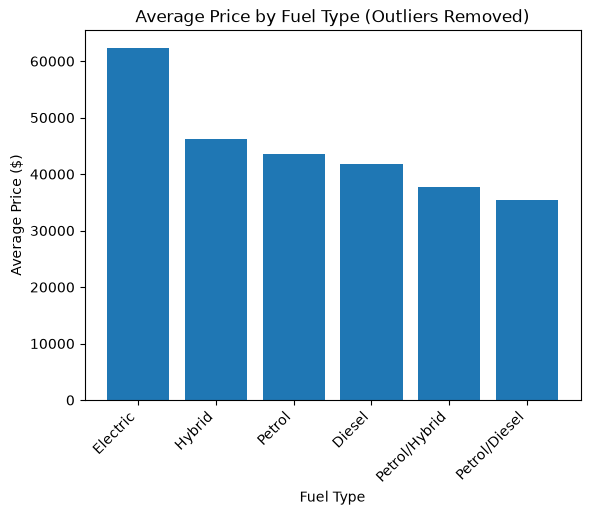

In [17]:
# Removing price outliers using the IQR method before comparing fuel types
Q1 = df['Car Prices Final'].quantile(0.25)
Q3 = df['Car Prices Final'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

df_no_outliers = df[df['Car Prices Final'] <= upper_bound]

print(f"Removed {len(df) - len(df_no_outliers)} outlier rows out of {len(df)}")
print(f"Upper price bound: ${upper_bound:,.0f}")

fuel_avg_clean = df_no_outliers.groupby('Fuel Types')['Car Prices Final'].mean()
fuel_counts_clean = df_no_outliers['Fuel Types'].value_counts()
fuel_avg_clean_filtered = fuel_avg_clean[fuel_counts_clean >= 10].sort_values(ascending=False)

plt.bar(fuel_avg_clean_filtered.index, fuel_avg_clean_filtered.values)
plt.xlabel('Fuel Type')
plt.ylabel('Average Price ($)')
plt.title('Average Price by Fuel Type (Outliers Removed)')
plt.xticks(rotation=45, ha='right')
plt.show()